<div style="background:linear-gradient(135deg,#082f49 0%,#0369a1 55%,#38bdf8 100%);border-radius:18px;padding:34px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#bae6fd;font-weight:700;text-transform:uppercase">Chapter 134 · Take It Further</div>
  <div style="font-size:34px;font-weight:900;line-height:1.1;margin:10px 0 6px">From Forecast to Decision &#183; Take It Further</div>
  <div style="font-size:15px;color:#e0f2fe;max-width:740px;line-height:1.6">Five extensions of the order decision: when the critical fractile flips below the forecast, how the order tracks the cost ratio, using an empirical predictive distribution, the service-level tradeoff, and proof that a more accurate forecast yields a cheaper decision.</div>
  <div style="margin-top:16px;font-size:13px;color:#bae6fd">Statistics, Data Science and AI: A Visual Handbook · John Fisher · 2026</div>
</div>

# From Forecast to Decision: Take It Further
Five extensions of the Chapter 134 decision, each probing how the order should change: when the fractile **flips below** the forecast, how the order tracks the **cost ratio**, using an **empirical** predictive distribution, the **service-level** tradeoff, and proof that a **more accurate forecast** yields a cheaper decision. We start by rebuilding the forecast and costs.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import seaborn as sns   # seaborn = high-level statistical plots (heatmaps, pairplots, count/bar plots)
from matplotlib.colors import ListedColormap
EM="#0284c7"; DEEP="#075985"; LIGHT="#bae6fd"; INK="#1a2138"; GRID="#e6e9f2"; RED="#ef4444"; AMBER="#d97706"; GREEN="#059669"; BLUE="#2563eb"; PUR="#9333ea"; GREY="#94a3b8"; SLATE="#475569"; ORG="#0284c7"; CYAN="#0891b2"
plt.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white","figure.dpi":110,"font.size":11,
   "axes.edgecolor":GRID,"axes.grid":True,"grid.color":GRID,"axes.axisbelow":True,"axes.spines.top":False,
   "axes.spines.right":False,"axes.titlesize":12,"axes.titleweight":"bold","legend.frameon":False})
sns.set_style("whitegrid")
BASE="https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"

In [2]:
from scipy import stats
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import warnings; warnings.filterwarnings('ignore')

<div style="background:#ecfeff;border-left:5px solid #0891b2;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#0e7490;letter-spacing:1px">RECAP &#183; REBUILD</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">The forecast, errors, and costs</div>
<div style="color:#4a5578;margin-top:6px">Everything from Chapter 134 in a few cells.</div>
</div>

In [3]:
try: raw = pd.read_excel('../../data/case-study-from-forecast-to-decision--product_demand.xlsx', sheet_name='Data')
except FileNotFoundError: raw = pd.read_excel(BASE + 'case-study-from-forecast-to-decision--product_demand.xlsx', sheet_name='Data')
raw['date']=pd.to_datetime(raw['date']); s = raw.set_index('date')['demand'].asfreq('D')
H=60; train,test=s[:-H],s[-H:]
hw = ExponentialSmoothing(train, trend='add', seasonal='add', seasonal_periods=7).fit(); hw_fc = hw.forecast(H).values
resid = train.values - hw.fittedvalues.values; sd = float(np.std(resid))
def cost(demand, order, Cu, Co): return Cu*np.maximum(demand-order,0) + Co*np.maximum(order-demand,0)
def order_q(Cu, Co): return hw_fc + stats.norm.ppf(Cu/(Cu+Co))*sd
print('rebuilt: HW forecast + error sd %.1f units' % sd)

rebuilt: HW forecast + error sd 26.6 units


<div style="background:#f0f9ff;border-left:5px solid #0284c7;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#075985;letter-spacing:1px">EXTENSION 1 &#183; WHEN THE FRACTILE FLIPS</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Perishable: waste is expensive</div>
<div style="color:#4a5578;margin-top:6px">Now you order BELOW the forecast.</div>
</div>

In [4]:
for Cu,Co,label in [(8,2,'stockout expensive'),(2,8,'waste expensive (perishable)')]:
    fr=Cu/(Cu+Co); buf=stats.norm.ppf(fr)*sd
    print('%-28s fractile %.2f -> order %+.0f units vs forecast' % (label, fr, buf))
print('when leftovers cost more than stockouts, the optimal order drops BELOW the forecast -> deliberately risk selling out')

stockout expensive           fractile 0.80 -> order +22 units vs forecast
waste expensive (perishable) fractile 0.20 -> order -22 units vs forecast
when leftovers cost more than stockouts, the optimal order drops BELOW the forecast -> deliberately risk selling out


The critical fractile can point either way. When **stockouts** are the expensive error (Cu &gt; Co) you carry a buffer **above** the forecast; when **waste** is expensive (Co &gt; Cu, a highly perishable item) the fractile falls below 0.5 and you order **below** the forecast, accepting some stockouts to avoid costly spoilage. Same forecast, opposite decision, set entirely by the cost ratio.

<div style="background:#f0f9ff;border-left:5px solid #0284c7;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#075985;letter-spacing:1px">EXTENSION 2 &#183; THE ORDER TRACKS THE COST RATIO</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">How much buffer?</div>
<div style="color:#4a5578;margin-top:6px">Sweep the ratio, watch the order move.</div>
</div>

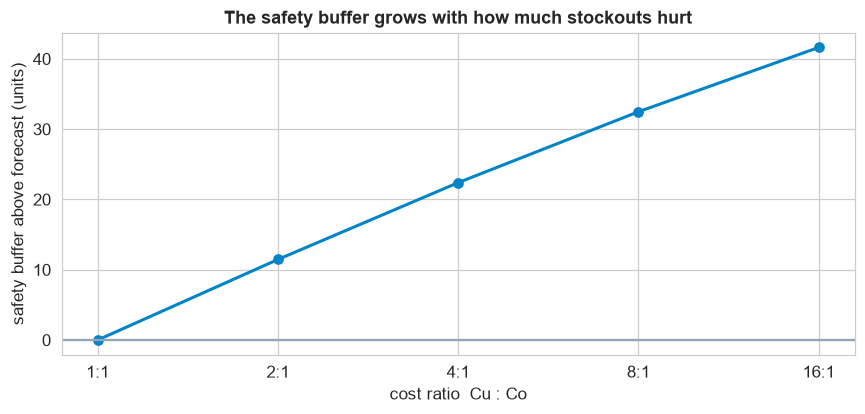

ratio 1:1 -> order the forecast (no buffer); 8:1 -> a large buffer. The decision is a dial on the cost ratio.


In [5]:
ratios=[1,2,4,8,16]; buffers=[stats.norm.ppf(r/(r+1))*sd for r in ratios]
fig,ax=plt.subplots(figsize=(8,3.9)); ax.plot(ratios, buffers, 'o-', color=EM, lw=2)
ax.axhline(0,color=GREY); ax.set(xscale='log', xlabel='cost ratio  Cu : Co', ylabel='safety buffer above forecast (units)', title='The safety buffer grows with how much stockouts hurt')
ax.set_xticks(ratios); ax.set_xticklabels([f'{r}:1' for r in ratios]); plt.tight_layout(); plt.show()
print('ratio 1:1 -> order the forecast (no buffer); 8:1 -> a large buffer. The decision is a dial on the cost ratio.')

The optimal order is a smooth **dial on the cost ratio**. At 1:1 (errors equally costly) you order the forecast exactly; the more a stockout hurts relative to a leftover, the bigger the buffer. Making the cost ratio explicit turns a fuzzy judgment call (&#8220;keep a bit extra&#8221;) into a precise, defensible number.

<div style="background:#f0f9ff;border-left:5px solid #0284c7;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#075985;letter-spacing:1px">EXTENSION 3 &#183; EMPIRICAL PREDICTIVE DISTRIBUTION</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Do not assume normal</div>
<div style="color:#4a5578;margin-top:6px">Use the real error quantiles.</div>
</div>

In [6]:
Cu,Co=8.0,2.0; fr=Cu/(Cu+Co)
q_normal = hw_fc + stats.norm.ppf(fr)*sd
q_emp    = hw_fc + np.quantile(resid, fr)          # empirical residual quantile
print('80th-percentile order, normal assumption : mean %.0f units' % q_normal.mean())
print('80th-percentile order, empirical residuals: mean %.0f units' % q_emp.mean())
print('avg cost  normal %.0f  vs  empirical %.0f' % (cost(test.values,q_normal,Cu,Co).mean(), cost(test.values,q_emp,Cu,Co).mean()))
print('if the errors are skewed or fat-tailed, the empirical quantile is safer than a normal one')

80th-percentile order, normal assumption : mean 252 units
80th-percentile order, empirical residuals: mean 252 units
avg cost  normal 69  vs  empirical 69
if the errors are skewed or fat-tailed, the empirical quantile is safer than a normal one


The normal shortcut (forecast + z &#215; sd) assumes symmetric, bell-shaped errors. Real forecast errors are often **skewed or fat-tailed**, so a more robust order uses the **empirical quantile** of the backtest residuals directly. Here the two agree (these errors are roughly symmetric), but on skewed real-world demand they diverge, and when they do you should trust the data over the bell curve, because the tail is where the expensive mistakes live.

<div style="background:#f0f9ff;border-left:5px solid #0284c7;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#075985;letter-spacing:1px">EXTENSION 4 &#183; SERVICE LEVEL vs COST</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Pick your fill rate</div>
<div style="color:#4a5578;margin-top:6px">They are two views of the same dial.</div>
</div>

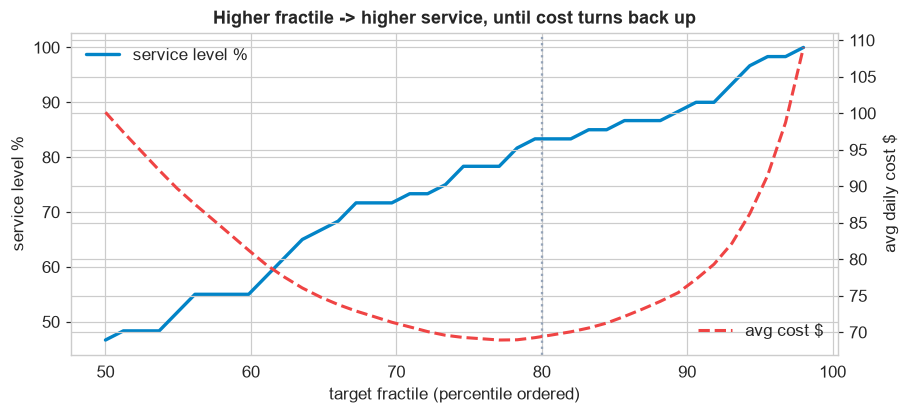

In [7]:
frs=np.linspace(0.5,0.98,40)
svc=[np.mean(test.values <= hw_fc+stats.norm.ppf(q)*sd)*100 for q in frs]
cst=[cost(test.values, hw_fc+stats.norm.ppf(q)*sd, 8,2).mean() for q in frs]
fig,ax=plt.subplots(figsize=(8.4,3.9)); ax2=ax.twinx()
ax.plot(frs*100, svc, color=EM, lw=2.2, label='service level %'); ax2.plot(frs*100, cst, color=RED, lw=2, ls='--', label='avg cost $')
ax.axvline(80, color=GREY, ls=':'); ax.set(xlabel='target fractile (percentile ordered)', ylabel='service level %'); ax2.set_ylabel('avg daily cost $')
ax.legend(loc='upper left'); ax2.legend(loc='lower right'); ax.set_title('Higher fractile -> higher service, until cost turns back up'); plt.tight_layout(); plt.show()

The fractile is also a **service-level** knob: a higher order percentile means the shelf is stocked more often. But service and cost are linked, push the fractile too high and waste starts to dominate, so cost turns back up. The cost-optimal fractile (80% here) is the point that balances them; a manager can equally well pick a **target service level** and read off the order.

<div style="background:#f0f9ff;border-left:5px solid #0284c7;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#075985;letter-spacing:1px">EXTENSION 5 &#183; ACCURACY BUYS A BETTER DECISION</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Feed the worse forecast in</div>
<div style="color:#4a5578;margin-top:6px">The bad forecast costs more, even with the same rule.</div>
</div>

In [8]:
snaive = np.array([train.iloc[-7+(i%7)] for i in range(H)])
sd_sn = float(np.std(train.values[7:] - train.values[:-7]))   # seasonal-naive one-step error spread
def order_for(fc, sdv, Cu=8, Co=2): return fc + stats.norm.ppf(Cu/(Cu+Co))*sdv
c_hw = cost(test.values, order_for(hw_fc, sd), 8,2).mean()
c_sn = cost(test.values, order_for(snaive, sd_sn), 8,2).mean()
print('decision cost using Holt-Winters forecast : $%.0f/day' % c_hw)
print('decision cost using seasonal-naive forecast: $%.0f/day' % c_sn)
print('the MORE ACCURATE forecast yields the CHEAPER decision -> accuracy is worth real money')

decision cost using Holt-Winters forecast : $69/day
decision cost using seasonal-naive forecast: $193/day
the MORE ACCURATE forecast yields the CHEAPER decision -> accuracy is worth real money


Finally, the payoff loop: feeding the **less accurate** forecast through the exact same newsvendor rule produces a **more expensive** decision. Forecast accuracy is not an academic score, it flows straight through to the cost of the orders you place. A better forecast, and the Diebold-Mariano test that proves it, is worth real money at the decision.

## Take-it-further summary, in plain terms

- **The fractile can flip below the forecast** when waste costs more than stockouts.
- **The buffer is a dial on the cost ratio**: the more a stockout hurts, the more you carry.
- **Use the empirical error quantile** when forecast errors are skewed or fat-tailed.
- **Service level and cost are the same dial** viewed two ways; pick a target and read off the order.
- **A more accurate forecast yields a cheaper decision**, so accuracy is worth money.

---
<div style="text-align:center;color:#8b94b3;font-size:12px;margin-top:10px">Statistics, Data Science and AI: A Visual Handbook · © 2026 John Fisher</div>